In [77]:
import numpy as np 
import matplotlib.pyplot as plt

iris = np.genfromtxt('iris_full.csv', dtype = float, delimiter=',', skip_header = 1)

X = iris[:,:4]
y = iris[:,4]

intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((X,intercept), axis = 1)
m = X.shape[0]

print('X_b', X_b.shape)
print('y', y.shape)
print('m', m)



X_b (100, 5)
y (100,)
m 100


In [78]:
def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))

def predict(X, theta):    
    y_hat = sigmoid_function(np.dot(X, theta))
    return y_hat

def loss_function(y_hat,y):
    loss = (-y*np.log(y_hat) - (1-y)*np.log(1-y_hat)).mean()
    #loss = (-y.T.dot(np.log(y_hat)) - (1-y).T.dot(np.log(1-y_hat))).mean 

    #Trong numpy vector nhân với ma trận là element-wise( nhân từ phần tử của vector
    #với từng phần của ma trận)

    #việc tạo ra vector y = [1, 0 ,1,0] khi nhân với ma trận y_hat có dạng ma trận 2D dạng (row, 2 )
    """y_hat =[[0,2],
                [0,3],
                [0,4],
                [0.2],] thì 1*0,2 0*0,3 và tương tự nhân vậy"""
    """
    Chú ý là y_hat là vector cột 2 chiều
    """ 
    return loss




In [79]:
lr = 0.01
num_iter = 100
minibatch_size = 32

theta = np.array([0.1, 0.5, 0.1, 0.5, -0.1])
losses = []
accs   = []

for i in range(num_iter):
    shuffled_indices = np.random.permutation(m) #Tạo ra 1 mảng chứa các số từ 1->m-1, có vị trí ngẫu nhiên
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]

    for i in range(0, m, minibatch_size): #i = 0, 32, 64 , 96
        xi = X_b_shuffled[i:i+minibatch_size] # 0-> 32 - 1, 32 -> 64-1, 64 -> 96 -1
        yi = y_shuffled[i:i+minibatch_size]

        # compute output
        z = np.dot(xi, theta)
        y_hat = sigmoid_function(z)

        # compute loss
        loss = loss_function(y_hat, yi)

        # compute gradient
        gradient = np.dot(xi.T, (y_hat - yi)) / yi.size

        # update
        theta -= lr*gradient
        
        # ===========================
        # loss
        losses.append(loss)

        # accuracy
        preds = predict(xi, theta).round()
        acc = (preds == yi).mean()
        accs.append(acc)

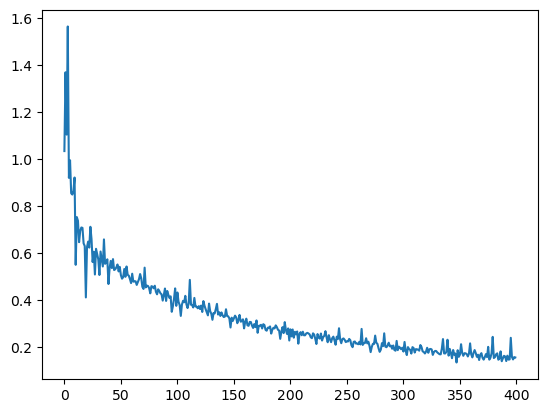

In [80]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.show()

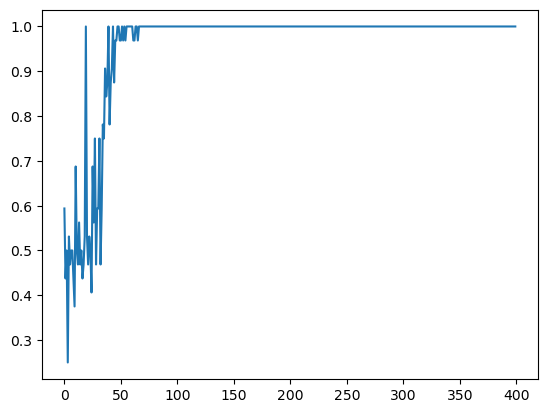

In [81]:
import matplotlib.pyplot as plt

plt.plot(accs)
plt.show()